# **PROJECT NAME** - Uber EDA Project

**Project Type** - EDA

**Contribution** - Individual

**Name** - Shivani Sharma

# **Project Summary-**

**Uber Technologies, Inc.** is an American multinational transportation company that provides ride-hailing
services, courier services, food delivery, and freight transport. 

It is headquartered in San Francisco, California,
and operates in approximately 70 countries and 15,000 cities worldwide.

It is the largest ridesharing company worldwide with over 150 million monthly active users and 6 million active drivers and couriers.

It coordinates an average of 28 million trips per day, and has coordinated 47 billion tripssince its inception in 2010.

In 2023, the company had a take rate (revenue as a percentage of gross bookings) of 28.7% for mobility services and 18.3% for food delivery.

We have given a dataset through which we have to analyze the demand and supply gap for Uber Company by doing EDA operation on given dataset.

# **GitHub Link -**  



# **Problem Statement**

**We have given a dataset on which we have to do EDA operation to analyze and solve problems for the Uber Demand Gap through it.**

The following are the business objective for this project:

1. To find the reason of cancellation of cab rides by drivers.

2. To find the solution to increase the transparency of cab ride fairs.

3. To find the permanent solution to customer problems so that to increase customer engagement and customer satisfaction rate.

4. To find various method to increase customer engagement to use this app over other apps and ultimately increase profits for the organization.

5. To find solution to increase safety of cab rides specially in night time.

# **1. Know Your Data**

**Import Libraries**

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
import statsmodels as stat
import geopandas as geo
import missingno as ms
import warnings
warnings.filterwarnings('ignore')

print("All libraries are imported sucessfully!!")

All libraries are imported sucessfully!!


**Dataset Loading**

In [2]:
# Load Dataset

md = pd.read_csv(r'F:/Hexa_Solutions/Data_Analytics_Part3/Assignment_given/Project Files/UBER Project/Project Files/UBER SUPPLY DEMAND GAPS/Uber Request Data.csv')


# **Dataset First View**

In [3]:
# Dataset first view

md.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25


In [4]:
# Dataset tail look

md.tail()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15/07/16 23:49,NaN
6741,6752,Airport,NaN,No Cars Available,15/07/16 23:50,NaN
6742,6751,City,NaN,No Cars Available,15/07/16 23:52,NaN
6743,6754,City,NaN,No Cars Available,15/07/16 23:54,NaN
6744,6753,Airport,NaN,No Cars Available,15/07/16 23:55,NaN


# **Dataset Rows & Columns count**

In [5]:
# Dataset Rows & Columns count

md.shape

(6745, 6)

# **Dataset Information**

In [6]:
# Dataset Info

md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


# **Duplicate Values**

In [7]:
# Dataset Duplicate Value Count

# Check for duplicate Values

duplicates = md.duplicated(keep=False)

#  Count the duplicate values

duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    6745
Name: count, dtype: int64


# **Missing Values/Null Values**

In [8]:
# Missing Values/Null Values Count

md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

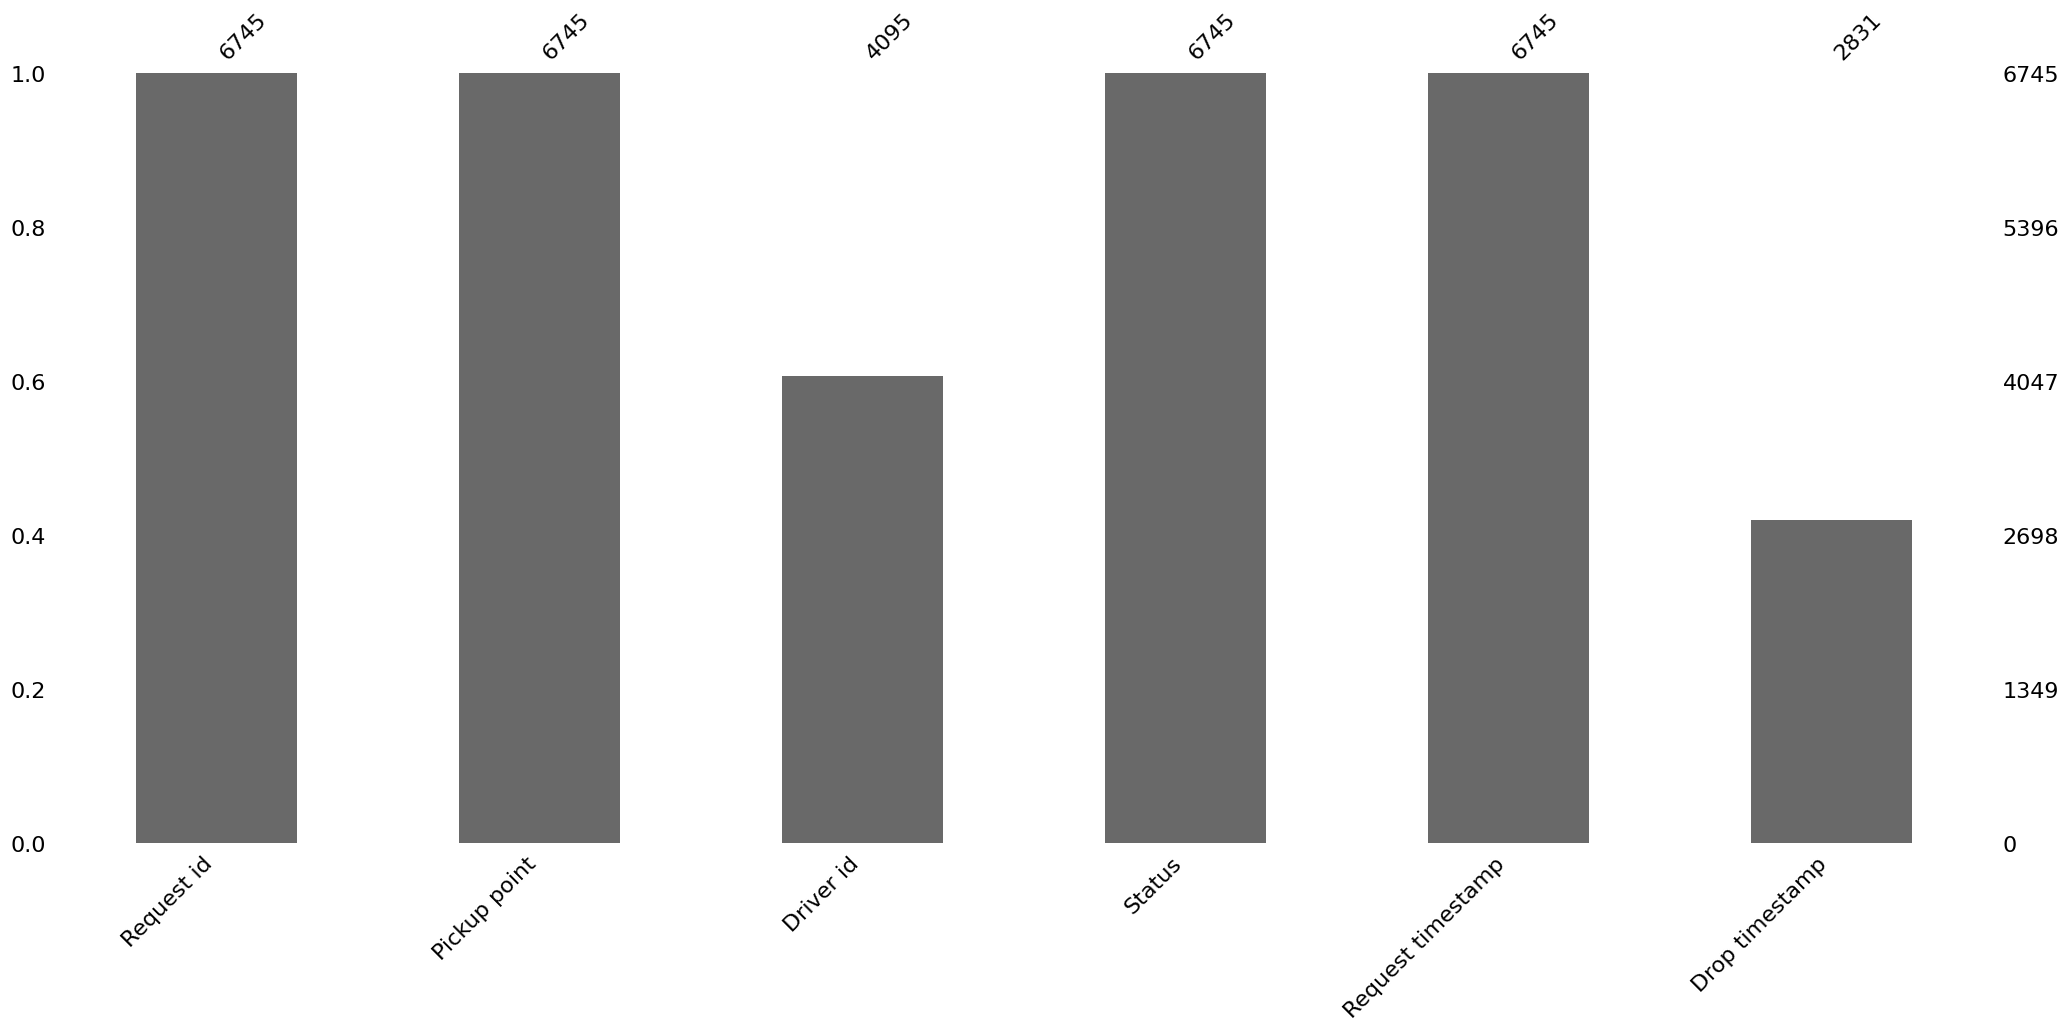

In [9]:
# Visualizing the missing values

ms.bar(md)
plt.show()

# **What did you know about your dataset?**

**The following are the major points about the dataset.**

1. The dataset contains 6 columns and 6745 rows.

2. There are no duplicate values in the dataset.

**Following 2 columns are having some missing values:**

1. Driver id - 2650
2. Drop timestamp - 3914

# **2. Understanding Your Variables**

In [10]:
# Dataset Columns

md.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')

In [11]:
# Dataset Describe

md.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


# **Variables Description**

**The following are the variables with their description**

**Column names---Description**

1. Request id----Customer Unique id who requested for the cab service through app.
2. Pickup Point----Pickup location to pickup the customer.
3. Driver id-------Unique Id of driver who is driving the cab.
4. Status----------status of trip that if it got completed, cancelled or no cabs are available.
5. Request timestamp----Request time and date when the customer requested for the cab services.
6. Drop timestamp-------Drop time and date when customer is dropped to their repective location.

The above are the descriptions for the varaibles present in the dataset.

# **Check Unique Values for each variable.**

In [12]:
# Check unique values for each variables

for x in md.columns:
    print(f"{x} - {md[x].nunique()}")

Request id - 6745
Pickup point - 2
Driver id - 300
Status - 3
Request timestamp - 4016
Drop timestamp - 2282


# **3. Data Wrangling**

**Data Wrangling Code**

In [13]:
# Write your code to make your dataset analysis ready.
# Checking for the null values in the dataset

md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [14]:
md.fillna({"Driver id": "Not Availabe"},inplace=True)

In [15]:
md.fillna({"Drop timestamp": "Not Availabe"},inplace=True)

In [16]:
# Check missing values are present or removed

md.isnull().sum()

Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
dtype: int64

# **What all manipulations have you done and insights you found?**

**The following manipulations we have done to our dataset.**

1. As there were no duplicates so no need of removing it.
2. There are total 2 columns having missing values which we replaced with Not Available value.

Driver id-----2650

Drop timestamp-----3914

# **4. Data Visualization, Storytelling & Experimenting with Charts: Understand the relationships between variables**

**Chart - 1**

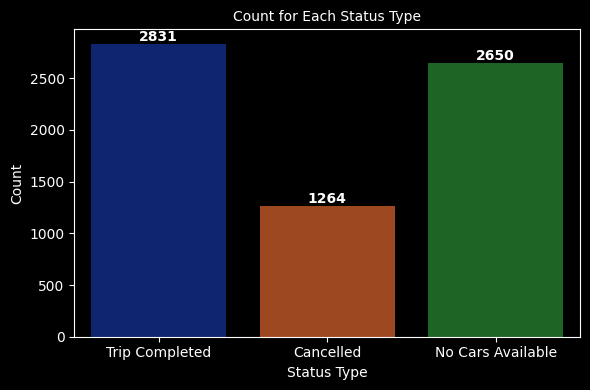

In [17]:
# Chart-1 Visualization code

plt.style.use('dark_background')
md.columns=md.columns.str.strip()
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Status', data=md, hue="Status", palette="dark", legend=0)
plt.title('Count for Each Status Type', fontsize = 10)
plt.xlabel('Status Type', fontsize=10)
plt.ylabel('Count', fontsize=10)
for p in ax.patches:
    count=int(p.get_height())
    x=p.get_x() + p.get_width()/2
    y=p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=10,
        color='white',
        fontweight='bold'
    )
    
plt.grid(False)
plt.tight_layout()
plt.show()

1. Why did you pick this chart?

The above bar plot gives clear count for status type.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-
    
    1. Highest count is for Trip completed status which is 2831.
    2. Second highest count is for No Cars Available status which is 2650.
    3. Lowest count is for Cancelled status which is 1264.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth?
Justify with specific reason.

The above insights shows that maximum cars have completed their trip but almost equal no of cars have not completed trip as they were not available at that moment,
which means uber has to increase its car numbers so as to increase availability of cars for customers and increase profits for the organization.

**Chart - 2**

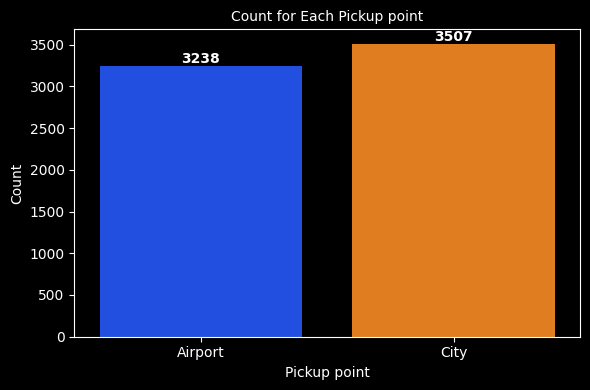

In [18]:
# Chart-2 Visualization code

plt.style.use('dark_background')
md.columns=md.columns.str.strip()
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Pickup point', data=md, hue="Pickup point", palette="bright", legend=0)
plt.title('Count for Each Pickup point', fontsize = 10)
plt.xlabel('Pickup point', fontsize=10)
plt.ylabel('Count', fontsize=10)
for p in ax.patches:
    count=int(p.get_height())
    x=p.get_x() + p.get_width()/2
    y=p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=10,
        color='white',
        fontweight='bold'
    )
    
plt.grid(False)
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

The above bar plot gives clear count for pickup point.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above barf plot:
    
    1. Highest count is for city pickup point which is 3507.
    2. Lowest count is for airport pickup point which is 3238.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that people often prefer Uber services inside city commute rather than airport commute which means company can do campaigns and offer some discounts on premium uber black service ir customer books it from airport to ultimately increase profits for the company.

**Chart 3**

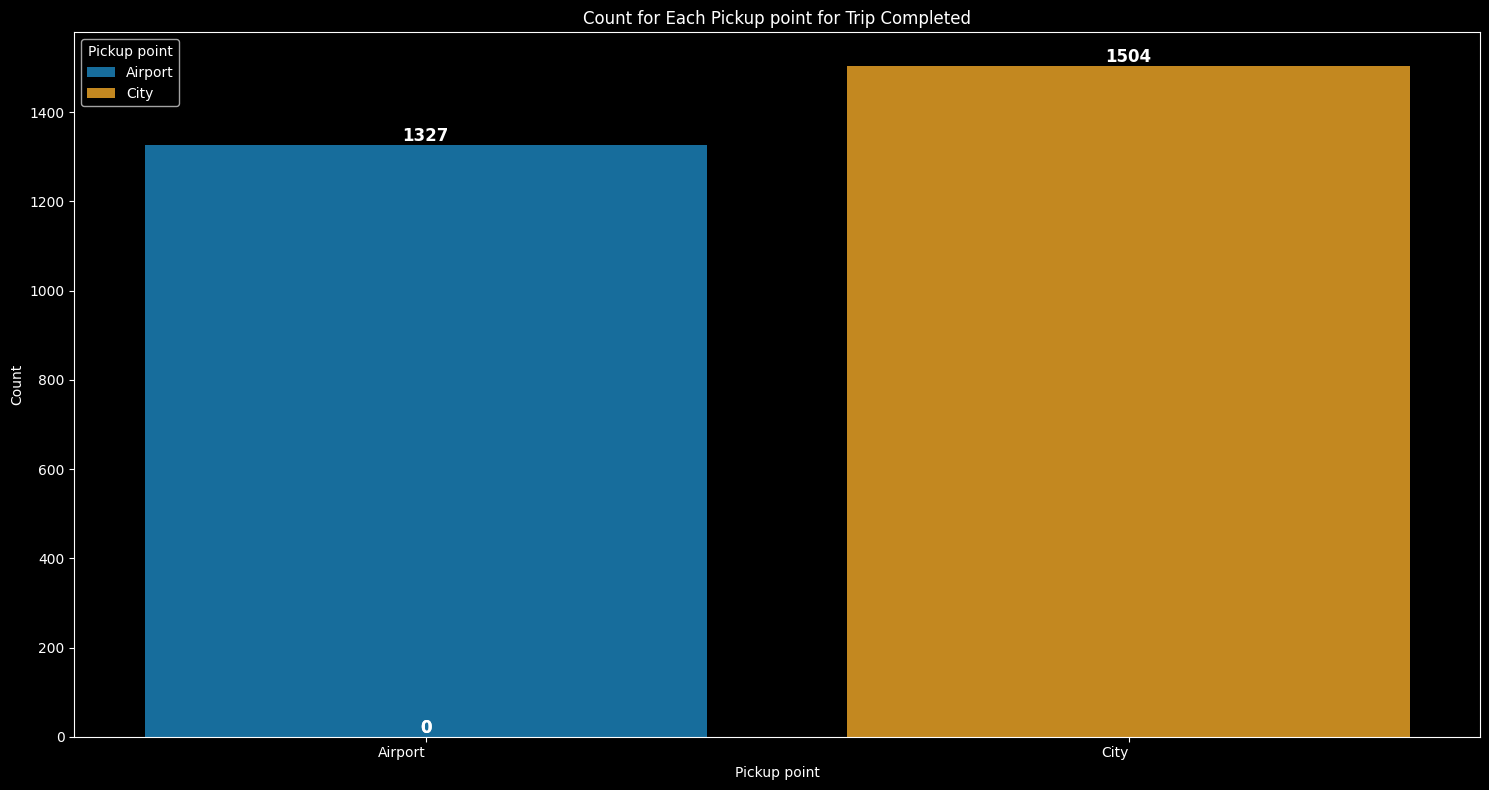

In [19]:
# Chart-3 Visualization code

plt.style.use('dark_background')
trip_c=md[md.Status=='Trip Completed'].groupby('Pickup point')['Pickup point'].count()
trip_c_1=pd.DataFrame(trip_c)

# Rename the count column
trip_c_1.rename(columns={'Pickup point' : 'count'}, inplace = True)
trip_c_1.reset_index(inplace = True)

# Create a bar plot
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=trip_c_1, x="Pickup point", y="count", hue="Pickup point", palette="colorblind", legend=True)

# Rotate x-axis labels for better readability

plt.xticks(rotation=0, ha="right")
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count for Each Pickup point for Trip Completed")

for p in ax.patches:
    count=int(p.get_height())
    x=p.get_x() + p.get_width()/2
    y=p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=12,
        color='white',
        fontweight='bold'
    )
    
plt.grid(False)
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

2. What is/are the insights found from the chart?

The following are the insights for the above bar plot:-
    
    1. For trip completed status the highest count is for the city which is 1504.
    2. For trip completed status the lowest count is for airplot which is 1327.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

As per the above insights, it shows that almost equal number of count is their for trip completion status for both pickup point which is great positive sign but, company can improve a little bit for airport pickup point which is great positive sign but, company can improve a little bit for airport pickup point to increase overall customer satisfaction and profits.

**Chart 4**

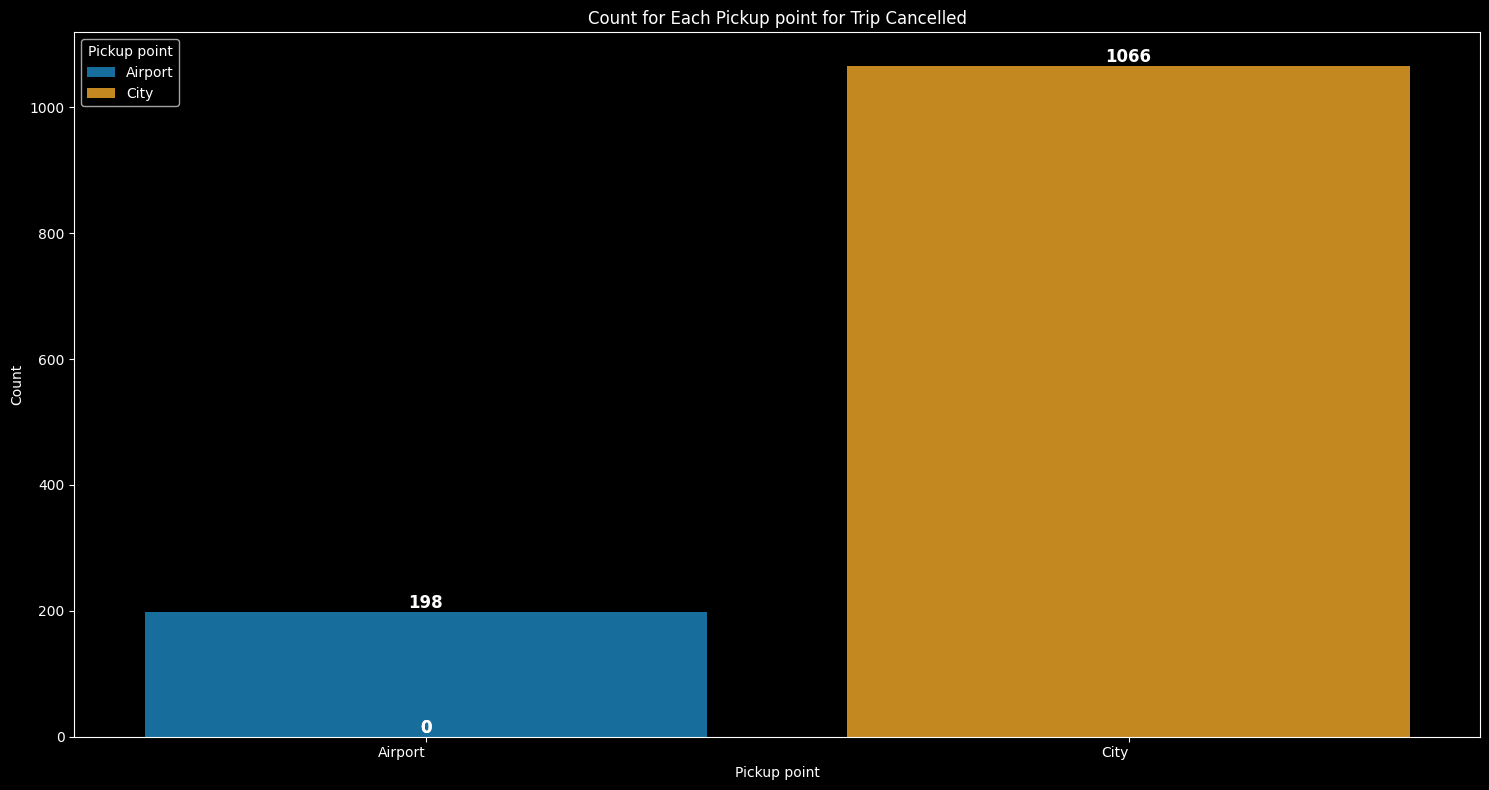

In [20]:
# Chart-4 Visualization code

plt.style.use('dark_background')
cancel = md[md.Status=='Cancelled'].groupby('Pickup point')['Pickup point'].count()
cancel_1 = pd.DataFrame(cancel)

# Rename the count column
cancel_1.rename(columns={'Pickup point' : 'count'}, inplace = True)
cancel_1.reset_index(inplace = True)

# Create a bar plot
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=cancel_1, x="Pickup point", y="count", hue="Pickup point", palette="colorblind", legend=True)

# Rotate x-axis labels for better readability

plt.xticks(rotation=0, ha="right")
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count for Each Pickup point for Trip Cancelled")

for p in ax.patches:
    count=int(p.get_height())
    x=p.get_x() + p.get_width()/2
    y=p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=12,
        color='white',
        fontweight='bold'
    )
    
plt.grid(False)
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:
    
    1. For Cancelled Trips status the highest count is for city which is 1066.
    2. For Cancelled Trips status the lowest count is for airport which is 198.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows a very negative aspect, as we know already that the count of pickpoint city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this; company should monitor on drivers who are cancelling rides inside city commute so as to increase future customer engagement and overall company reputation.

**Chart 5**

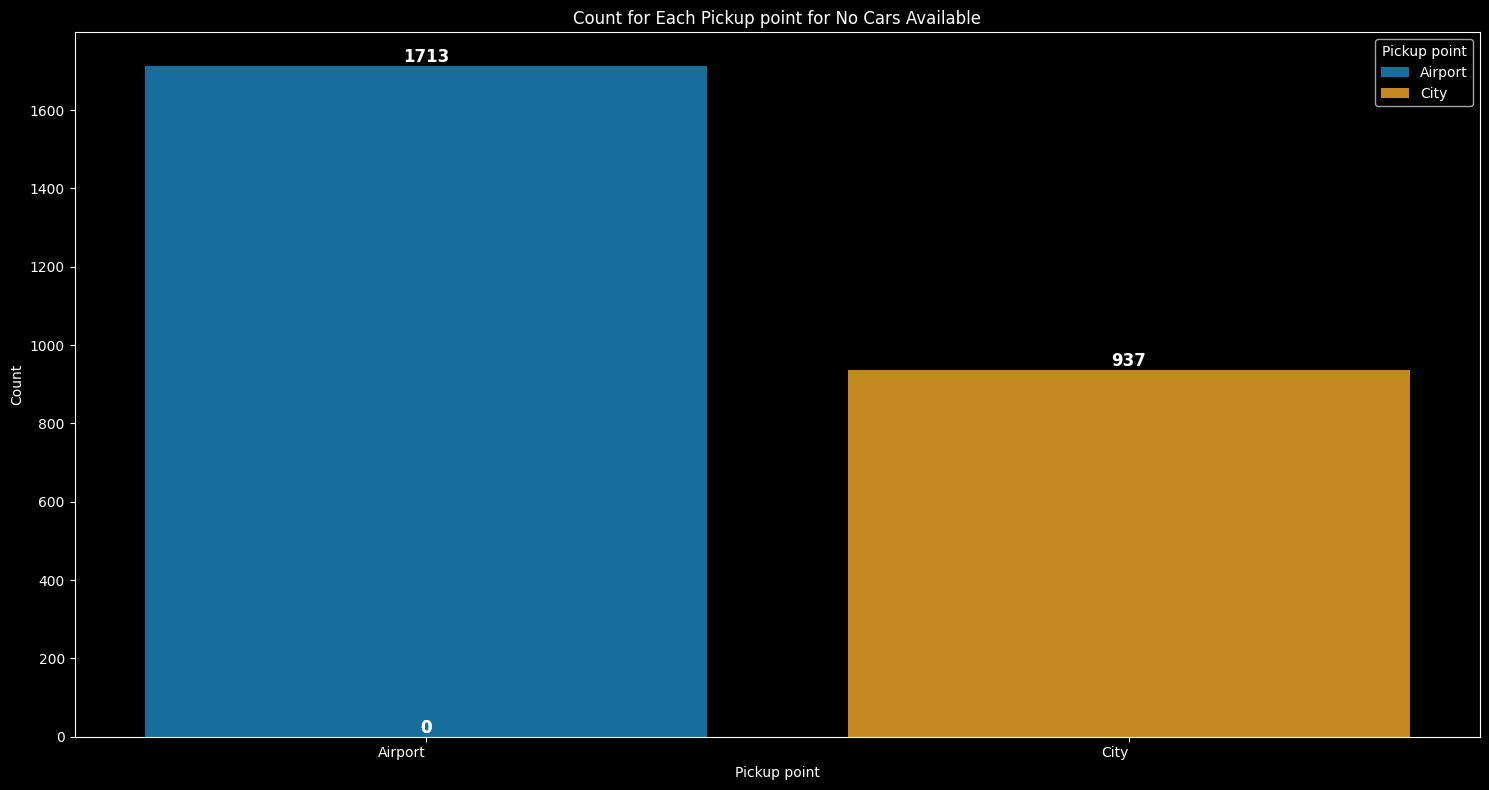

In [21]:
# Chart 5 - Visualization Code

plt.style.use('dark_background')
nocars = md[md.Status=='No Cars Available'].groupby('Pickup point')['Pickup point'].count()
nocars_1 = pd.DataFrame(nocars)

# Rename the count column
nocars_1.rename(columns={'Pickup point' : 'count'}, inplace = True)
nocars_1.reset_index(inplace = True)

# Create a bar plot
plt.figure(figsize=(15, 8))
ax = sns.barplot(data=nocars_1, x="Pickup point", y="count", hue="Pickup point", palette="colorblind", legend=True)

# Rotate x-axis labels for better readability

plt.xticks(rotation=0, ha="right")
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count for Each Pickup point for No Cars Available")

for p in ax.patches:
    count=int(p.get_height())
    x=p.get_x() + p.get_width()/2
    y=p.get_height()
    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=12,
        color='white',
        fontweight='bold'
    )
    
plt.grid(False)
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:
    
    1. For No Cars Available status the highest count is for Airport which is 1713.
    2. For No Cars Available status the lowest count is for City which is 937.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that maximum cars are not available at airport pickup point where the most of the business comes for any cab service company, so if uber wants to increase its profits it should provide more number of cars at airport so as to not miss the opportunity of earn and retain frequent flyers who commute through airport and use cab services.

**Chart 6**

In [22]:
# Chart 6 Visualization code

plt.style.use('dark_background')

# Ensure Clean column names
md.columns = md.columns.str.strip()

# Filter for pickup point = 'Airport'
airport_df = md[md['Pickup point'].str.strip()=='Airport']

# Group by Status and Count

type_count = airport_df['Status'].value_counts().reset_index()
type_count.columns = ['Status', 'Count']

# Create a tree map

fig = px.treemap(type_count,
                path=['Status'],
                values='Count',
                 title="Count of Status for Airport",
                color='Count',
                color_continuous_scale='RdBu')

# Show the plot

fig.show(renderer="iframe")

1. Why did you pick the specific chart?

The above tree map gives clear details when we hover over it and helps us to compare various variables in single tree map.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:
    
    1. Highest Count of Airport status is for No cars available which is 1713.
    2. Second highest count of airport status is for Trip Completed which is 1327.
    3. Lowest count of airport status is for Cancelled Trip which is 198.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that airport pickup point has less available cars because of which customers are preffering other cab services, if company wants to reduce or eliminate the competition then they have to allocate more cars at airport so as to increase customer engagement and profits.

**Chart 7**

In [23]:
# Chart 7 Visualization code

plt.style.use('dark_background')

# Ensure Clean column names
md.columns = md.columns.str.strip()

# Filter for pickup point = 'City'
city_df = md[md['Pickup point'].str.strip()=='City']

# Group by Status and Count

city_df_count = city_df['Status'].value_counts().reset_index()
city_df_count.columns = ['Status', 'Count']

# Create a tree map

fig = px.treemap(city_df_count,
                path=['Status'],
                values='Count',
                title="Count of Status for City",
                color='Count',
                color_discrete_map={'(?)':'Lightgrey', 'Lunch':'gold', 'Dinner':'darkblue'})

# Show the plot

fig.show(renderer="iframe")

1. Why did you pick the specific chart?

The above tree map gives clear details when we hover over it and helps us to compare various variables in single tree map.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:
    
    1. Highest Count of City status is for Trip Completed which is 1504.
    2. Second highest count of airport status is for Trip Cancelled which is 1066.
    3. Lowest count of airport status is for No Cars Available which is 937.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

As we know already that the count for pickup point city is greater than airport and here we can see that the maximum count of cancelled trips is for city pick up point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this; company should monitor on drivers who are cancelling rides inside city commute so as to increase future customer engagement and overall company reputation.

**Chart 8**

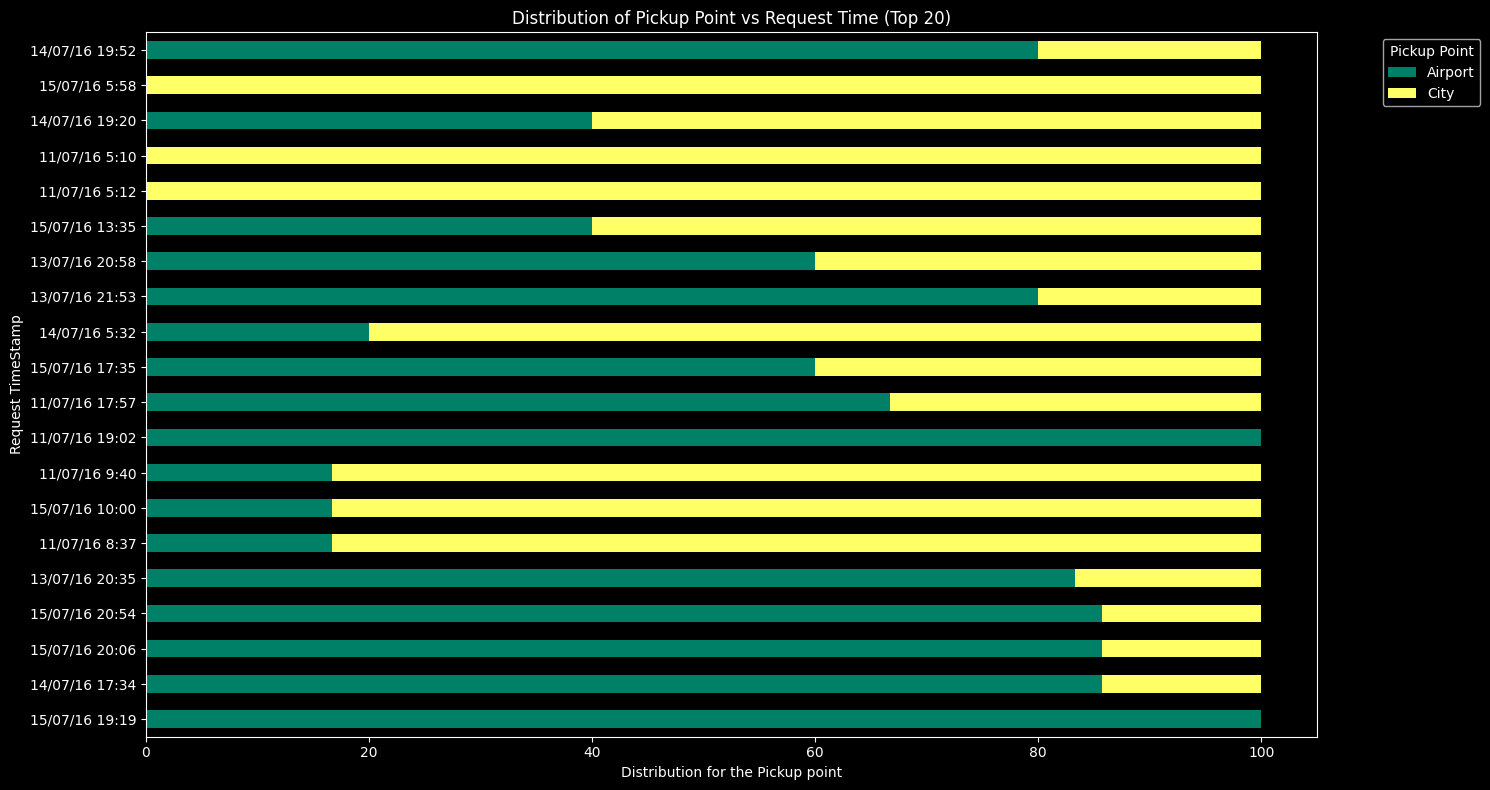

In [24]:
# Chart 8 Visualization code

P_1 = md.groupby(["Request timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)

P_11 = P_1.div(P_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)

top_P = P_1.sum(axis=1).sort_values(ascending = False).head(20).index
P_top20 = P_11.loc[top_P]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))
P_top20.plot(kind="barh", stacked=True, colormap="summer", ax=ax)

# Labels and titles
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Pickup Point vs Request Time (Top 20)")
plt.legend(title="Pickup Point", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:
    
1. Highest distribution for airport pickup point is for the request timestamps 19:02, 22:00 and 21:42 with common date as 11/07/2016.
    
2. Highest distribution for city pickup point is for the request timestamps 5:12, 5:10 and 8:42 with common date as 11/07/2016.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the customers are preffering city commute mostly in the morning time and airport commute in the evening/night time.

**Chart 9**

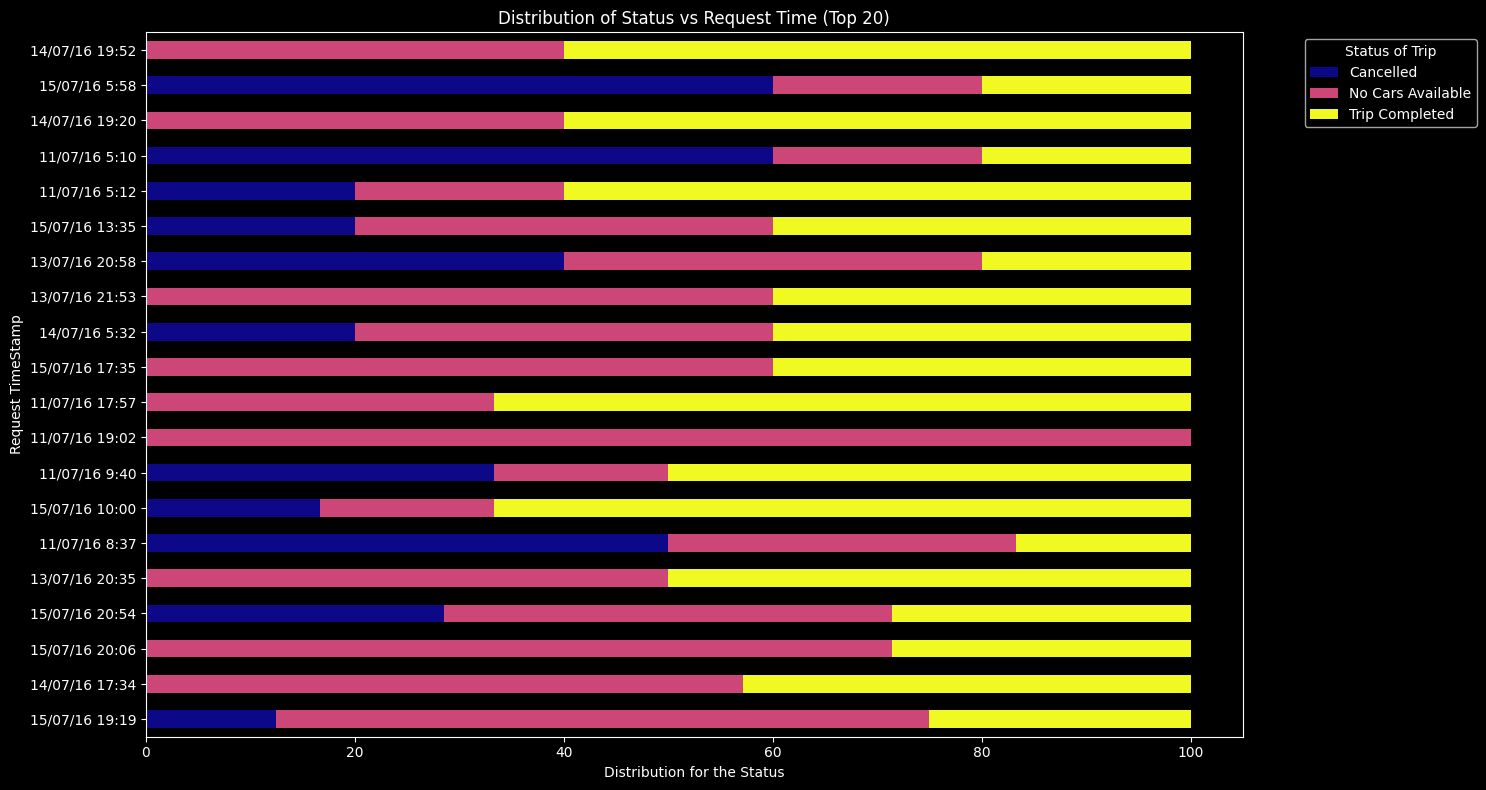

In [25]:
# Chart 9 Visualization code

S_1 = md.groupby(["Request timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)

S_11 = S_1.div(S_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)

top_S = S_1.sum(axis=1).sort_values(ascending = False).head(20).index
S_top20 = S_11.loc[top_S]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))
S_top20.plot(kind="barh", stacked=True, colormap="plasma", ax=ax)

# Labels and titles
plt.xlabel("Distribution for the Status")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Status vs Request Time (Top 20)")
plt.legend(title="Status of Trip", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:
    
1. No Cars Available (Evening Problem):
On 11/07/16 at 19:02, 100% of the trip requests failed because no cars were available. 

Overall, during evening hours (5:00 PM – 9:00 PM), a huge portion of customers could not get a ride due to a shortage of drivers.

2. High Cancellations (Morning Problem):
The highest percentage of cancelled trips happened in the early morning, around 5:10 AM on 11/07/16 and 5:58 AM on 15/07/16 (about 60% were cancelled). 

This shows that morning drivers are frequently rejecting trip requests.

3. Trip Completed (Overall Low Success Rate):
Across most peak hours, the percentage of completed trips rarely goes above 40% to 50%. 

This means the business is losing more than half of its potential earnings due to cancellations and driver shortages.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that no cars available status is mostly for evening/night time, cancelled status is mostly for morning time and Trip completed status has equal no of count for both evening/night and morning time. As per this morning drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab services.

**Chart 10**

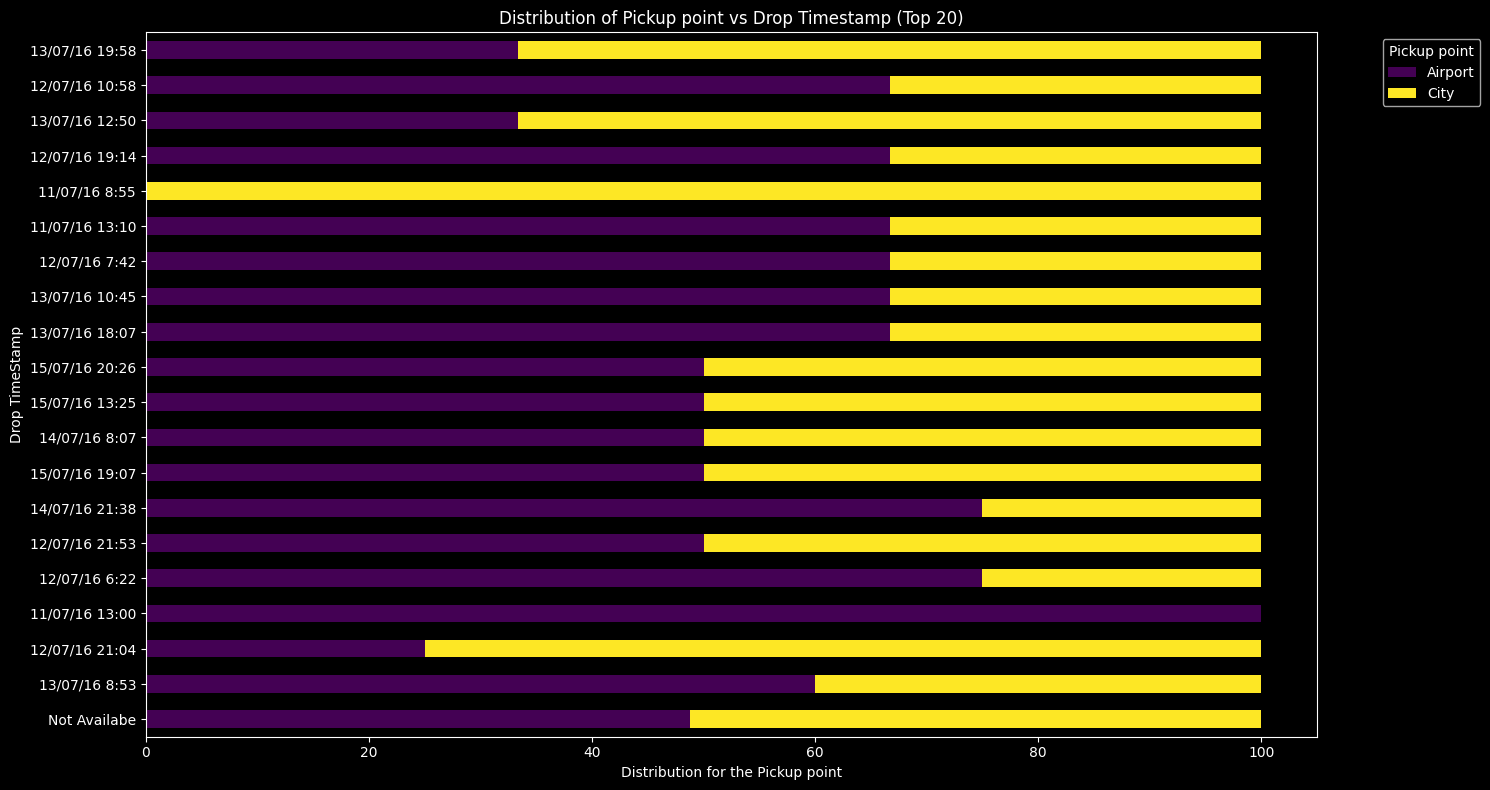

In [26]:
# Chart 10 Visualization code

Pd_1 = md.groupby(["Drop timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)

Pd_11 = Pd_1.div(Pd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)

top_Pd = Pd_1.sum(axis=1).sort_values(ascending = False).head(20).index
Pd_top20 = Pd_11.loc[top_Pd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))
Pd_top20.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)

# Labels and titles
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Drop TimeStamp")
plt.title("Distribution of Pickup point vs Drop Timestamp (Top 20)")
plt.legend(title="Pickup point", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:

Most peak drop timestamps are heavily dominated by Airport pickups (reaching up to 100% at times like 11/07/16 13:00), showing a severe structural imbalance where trip demand is heavily skewed toward airport origins rather than city pickups.
    
    
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

Optimizing driver allocation toward high-demand Airport pickup windows will reduce passenger wait times and capture maximum ride volume.

Negative Growth Risk:

Extreme demand skew towards the Airport creates severe one-way traffic imbalance, leaving drivers stranded without return fares from the City and causing high trip rejections that hurt overall revenue growth.



**Chart 11**

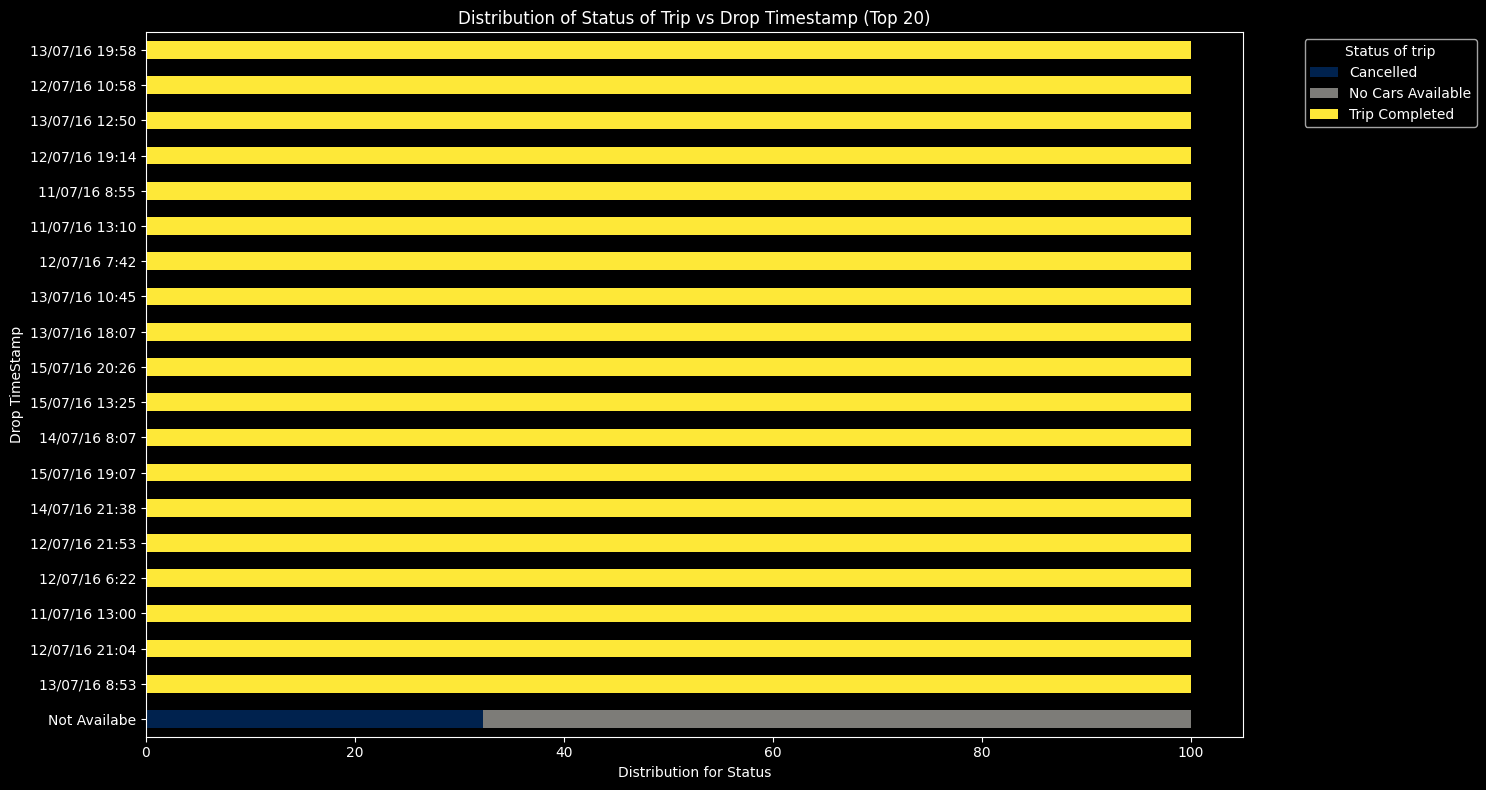

In [27]:
# Chart 11 Visualization code

Sd_1 = md.groupby(["Drop timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)

Sd_11 = Sd_1.div(Sd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)

top_Sd = Sd_1.sum(axis=1).sort_values(ascending = False).head(20).index
Sd_top20 =Sd_11.loc[top_Sd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))
Sd_top20.plot(kind="barh", stacked=True, colormap="cividis", ax=ax)

# Labels and titles
plt.xlabel("Distribution for Status")
plt.ylabel("Drop TimeStamp")
plt.title("Distribution of Status of Trip vs Drop Timestamp (Top 20)")
plt.legend(title="Status of trip", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

2. What is/are the insight(s) found from the chart?

The following are the insights from the above multi-bar plot:

1. All the top 20 recorded Drop Timestamps are associated with Trip Completed status, indicating that a Drop Timestamp is          recorded only for successfully completed trips.

2. There are no Cancelled or No Cars Available trips among the top 20 Drop Timestamp records shown in the chart.

3. The “Not Available” Drop Timestamp category contains unsuccessful trips, with No Cars Available accounting for a larger          proportion than Cancelled trips.

4. The chart highlights a clear relationship between the availability of a Drop Timestamp and trip completion, as completed         trips have recorded drop times while unsuccessful trips generally have no Drop Timestamp.
    
3. Will the gained insights help creating a positive business impact?

All top drop timestamps are associated with completed trips, while cancelled and unsuccessful requests have no recorded drop timestamp. Among requests with unavailable drop timestamps, ‘No Cars Available’ accounts for the majority, indicating that vehicle availability is a significant factor behind unsuccessful trips.

**Chart 12**

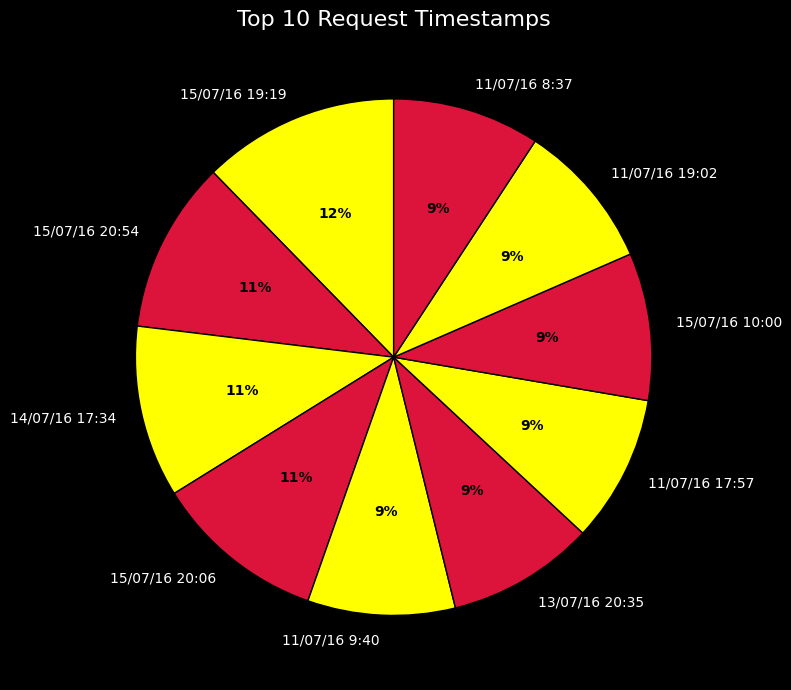

In [28]:
# Chart 12 Visualization code

co = md['Request timestamp'].value_counts().head(10)

# No conversion to int here
plt.figure(figsize=(15, 7))
co.plot(
        kind='pie',
        labels=co.index,  # keep as strings
        autopct=lambda p: '{:.0f}%'.format(p),
        colors=['yellow', 'crimson'],
        startangle=90,
        wedgeprops={'edgecolor' : 'black'},
        )

ax = plt.gca()
for t in ax.texts:
    if '%' not in t.get_text():
        t.set_color('white')
        
for t in ax.texts:
    if '%' in t.get_text():
        t.set_color('black')
        t.set_fontweight('bold')
        
plt.title('Top 10 Request Timestamps', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

The above pie chart gives distribution of request timestamps and help us to compare each of them with each other easily.

2. What is/are the insight(s) found from the chart?

The following are the insights for the above pie chart:-

    1. The highest distribution is for the request time stamps 19:19, with 12% value.
    2. The lowest distribution is for the request time stamps 9:40, 20:35, 17:57, 10:00 and 19:02 with 9% value each.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

The above insight can significantly create a positive business impact by helping Uber identify high-demand peak time windows (e.g., peak timestamp 19:19 holding the highest 12% share, alongside morning and late evening peaks like 9:40, 10:00, 17:57, 19:02, and 20:35 holding 9% share each). 

Negative Growth Risks & Mitigation:

- Threat: Unmanaged driver supply during these concentrated peak request timestamps leads to severe cab unavailability and higher cancellation rates, directly resulting in lost revenue and customer dissatisfaction.

- Business Solution: Uber can leverage this data to implement dynamic pricing (surge pricing) and incentives for drivers to remain active during these specific peak timestamp windows, ensuring maximum ride fulfillments and positive revenue growth.


**Chart 13**

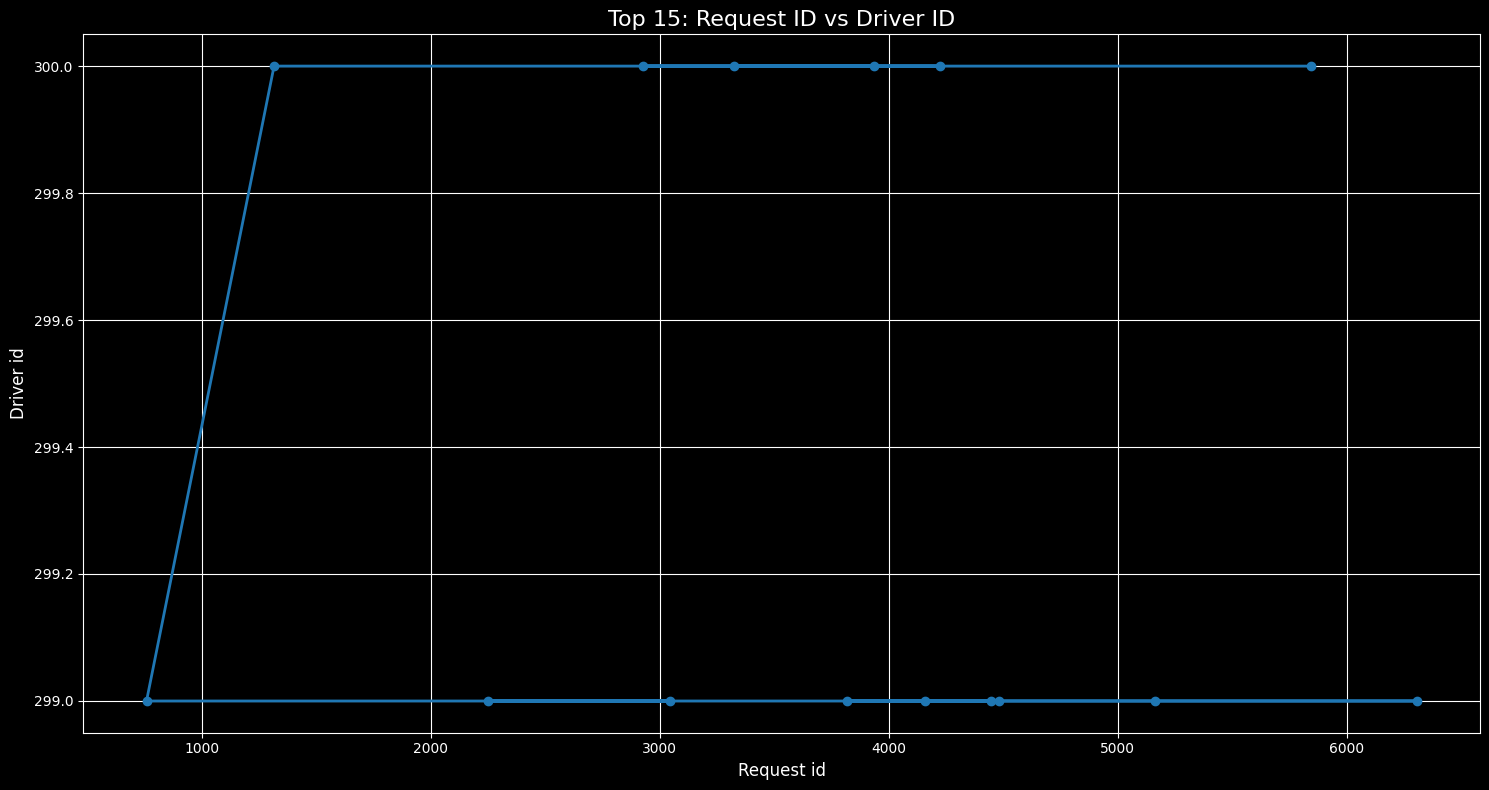

In [29]:
# Chart 13 Visulaization code

plt.style.use('dark_background')

# Clean column names

md.columns = md.columns.str.strip()

# Optional: Convert columns to numeric (in case they're strings)

md['Driver id'] = pd.to_numeric(md['Driver id'], errors='coerce')
md['Request id'] = pd.to_numeric(md['Request id'], errors='coerce')

# Drop rows with missing values

md = md.dropna(subset=['Driver id', 'Request id'])

# Sort by Driver id descending and take top 15
top_rd = md[['Request id', 'Driver id']].sort_values(by='Driver id', ascending=False).head(15)

# Plot

plt.figure(figsize=(15, 8))
plt.plot(top_rd['Request id'], top_rd['Driver id'], marker="o", color='tab:blue', linestyle='-', linewidth=2)

plt.xlabel("Request id", fontsize=12)
plt.ylabel("Driver id", fontsize=12)
plt.title("Top 15: Request ID vs Driver ID", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

1. Why did you pick the specific chart?

The above line chart is best for analyzing trends over a period of time for numerical variables.

2. What is/are the insight(s) found from the chart?


    1. Top Driver Activity: The line plot shows the relationship between the highest Driver IDs (sorted in descending order, ranging from 300.0 downwards) and their corresponding Request IDs.
    

    2. High Request ID Range: Most of the top driver IDs are mapped to higher Request ID values(around 6000+), indicating that these trips correspond to requests made toward the later phase/days of the dataset period.
    

    3. Driver Allocation Uniformity: The plot shows a consistent horizontal distribution near the top     range (Driver ID 300), which reflects that driver IDs are assigned sequentially or uniformly across incoming request IDs.
    
3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Positive Business Impact:

- Analyzing driver-wise trip distribution helps Uber identify top-performing drivers and track operational efficiency.

Negative Growth Risk & Reason:

- Risk: Uneven request allocation among drivers can lead to driver dissatisfaction or burnout if a few driver IDs handle disproportionate requests during peak hours.

- Justification: Ensuring automated, fair algorithm dispatching across all active driver IDs prevents idle driver time, maintains high fulfillment rates, and ultimately drives positive business growth.



**Chart 14 - Heat Map**

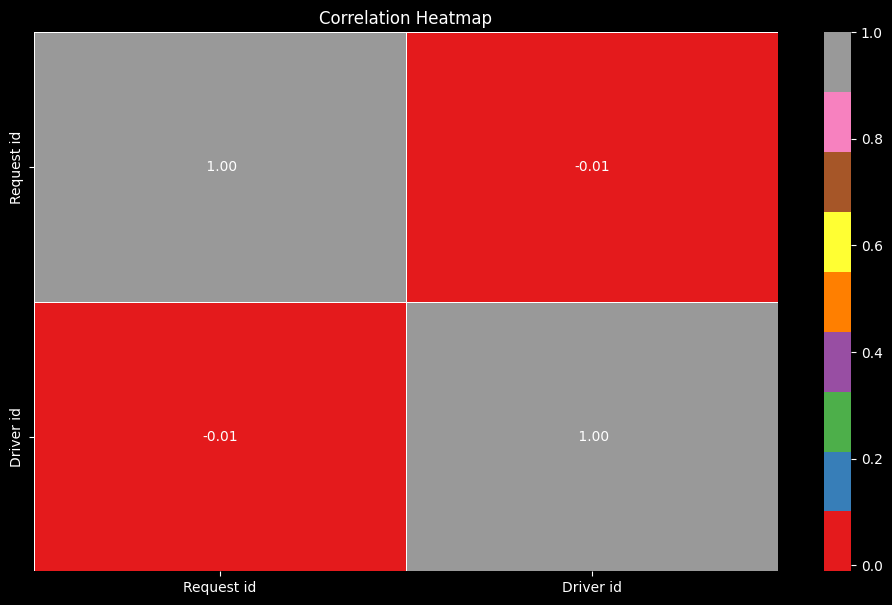

In [30]:
# Correlation Heatmap Visualization code

plt.style.use('dark_background')
numerical = md.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical.corr().fillna(0)
plt.figure(figsize=(12, 7))
sns.heatmap(corr_matrix, annot=True, cmap="Set1", fmt=" .2f", linewidth=0.5)
plt.title("Correlation Heatmap")
plt.show()

1. Why did you pick the specific chart?

The above heatmap is good for analyzing the correlation between various numerical values with each other and itself.

2. What is/are the insight(s) found from the chart?

The insight suggests request id and driver id have correlation as 1 with themselves.

**Chart 15 - Pair Plot**

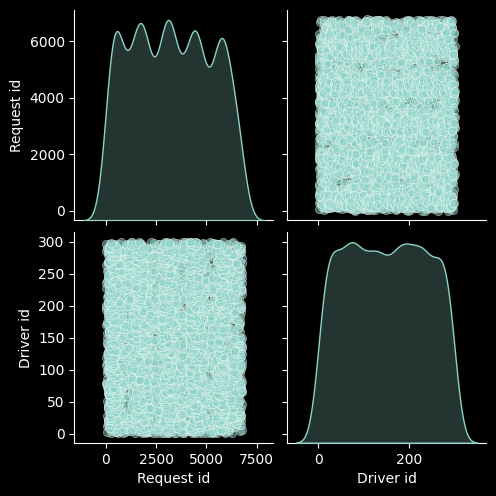

In [32]:
# Pair Plot visulaization code

plt.style.use('dark_background')
numerical = md.select_dtypes(include=['int64', 'float64'])
numerical = numerical.dropna(axis=1, thresh=len(numerical) * 0.8)
sns.pairplot(numerical, diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

1. Why did you pick the specific chart?

A Pair Plot allows us to visualize distributions, pairwise correlations, and potential patterns across all numerical fields in a single grid layout.

2. What is/are the insight(s) found from the chart?

**1. Uniform Scatter/No Correlation:** The scatter plot shows a dense, uniform rectangular block, indicating no correlation between Request id and Driver id.

**2. Even Data Distribution:** The diagonal Kernel Density Estimate (KDE) plots show that requests and assigned drivers are evenly distributed across the entire dataset without severe clustering.

3. Will the gained insights help create a positive business impact? 

Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**

**Data Integrity Check:** It confirms that ID columns are arbitrary continuous identifiers rather than correlated metrics, validating that further feature engineering (like time-based analysis) is required to uncover true supply-demand drivers.

**Insights Leading to Negative Growth:**

**1. No Direct Risk from IDs:** Since Request id and Driver id are purely administrative identifiers, this plot itself does not show operational decline.

**2.Analytic Overhead (Caution):** Plotting raw IDs without temporal or categorical breakdown does not expose actual business bottlenecks , which can lead to missed operational risks if relied upon alone.

## Solutions to Business Objectives

Based on the exploratory data analysis (EDA) and key findings across different time slots and pickup locations, the following strategic solutions are proposed to address Uber's demand-supply gap:

### 1. Address High Morning Cancellations in the City (05:00 AM - 10:00 AM)
* **Pre-Allocation & Destination Incentives:** Introduce guaranteed bonus payouts or priority return-ride dispatching for drivers accepting early morning airport trips from the city to eliminate driver reluctance and cancellation rates.
* **Advance Booking Assurance:** Implement a pre-scheduled booking window for airport-bound passengers with advance driver assignment to reduce last-minute cancellations.

### 2. Solve Night Supply Shortage at the Airport (05:00 PM - 11:00 PM)
* **Dynamic Surge & Shift Incentives:** Apply targeted surge pricing at the airport during peak incoming flight hours (17:00 – 22:00) and offer night-shift bonuses to drivers repositioning to the airport buffer zones.
* **Flight Schedule Integration:** Partner with airport authorities/flight APIs to align driver surge alerts with real-time flight landing schedules, ensuring adequate cab availability right when passenger volume peaks.

### 3. Enhance Fare Transparency and Customer Trust
* **Upfront Fare Lock & Fare Breakdown:** Display clear, upfront fare breakdowns (base fare, distance, time, and surge component) on the rider app before booking confirmation to increase trust and transparency.
* **Fair Driver Earnings Dashboard:** Provide drivers with clear earning estimates per trip to reduce arbitrary ride cancellations based on destination preference.

### 4. Improve Safety Standards (Especially for Night Rides)
* **Enhanced Safety Features:** Mandate real-time GPS tracking shareable with emergency contacts, integrated SOS buttons, and mandatory driver facial verification before starting late-night trips.
* **Driver Ratings & Verification:** Enforce strict background checks and prioritize top-rated, background-verified drivers for late-night airport pickups.

### 5. Drive Long-term Customer Engagement & Retention
* **Uber Black / Premium Loyalty Programs:** Introduce targeted discounts and loyalty rewards for frequent airport flyers using Uber Black or premium services.
* **Driver Performance Rewards:** Reward drivers who maintain high trip completion rates during peak demand hours with lower platform commission fees or priority trip matching.

## Conclusion

Through comprehensive Exploratory Data Analysis (EDA) on the Uber Supply-Demand Gap dataset, we identified significant operational bottlenecks in cab availability and ride completion rates across different pickup locations and time windows:

1. **Supply Bottleneck at Airport (Evening/Night Peak):** 
   The highest demand-supply mismatch occurs at the **Airport during late evening hours (17:00 – 22:00)**, resulting in over **1,700 "No Cars Available"** requests. This issue is primarily driven by a surge in incoming flights paired with a shortage of drivers willing or available to head toward the airport without guaranteed return trips.

2. **High Cancellation Bottleneck in City (Early Morning Peak):** 
   The highest number of **ride cancellations (~1,066)** occurs during **early morning hours (05:00 – 10:00)** for **City pickup points**. Drivers frequently cancel airport-bound rides due to the anticipation of long idle waiting times at the airport before receiving a return ride.

3. **Core Driver Dynamics:** 
   Trip completion rates are nearly balanced across both pickup points during normal hours, but peak-hour demand distributions create severe localized deficits that directly impact revenue and customer satisfaction.

### **Final Takeaway for Business Growth:**
By implementing **targeted morning driver incentives for airport drops, night-time surge pricing, automated destination dispatching, and flight-schedule integration**, Uber can effectively bridge the supply-demand gap. Resolving these bottlenecks will ensure higher trip completion rates, improved driver earnings, better customer retention, and long-term profitable growth for the organization.